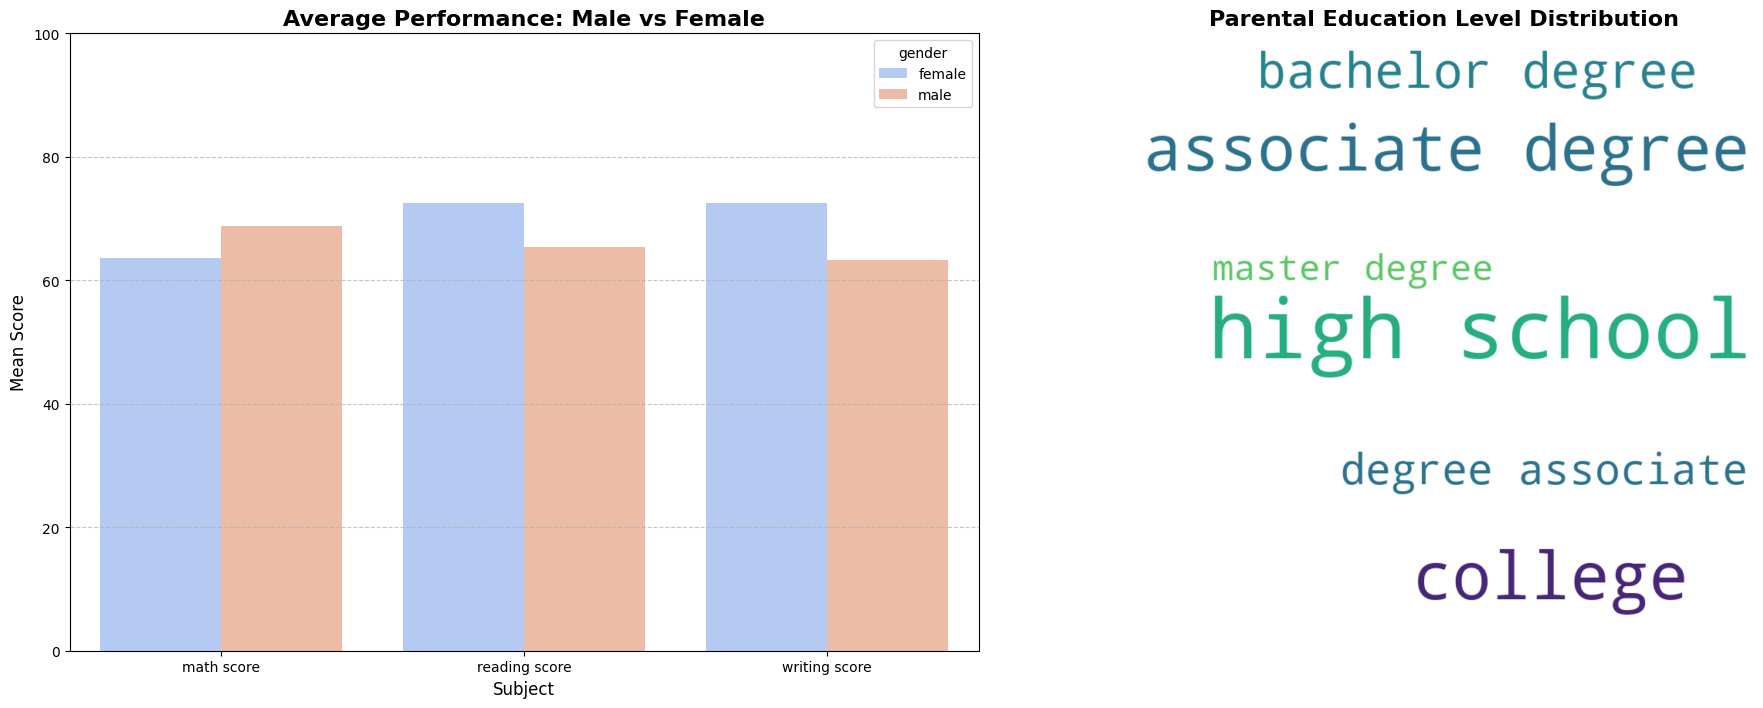

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

df = pd.read_csv('StudentsPerformance.csv')

gender_scores = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean().reset_index()

df_plot = gender_scores.melt(id_vars='gender', var_name='Subject', value_name='Average Score')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=df_plot, x='Subject', y='Average Score', hue='gender', palette='coolwarm', ax=axes[0])
axes[0].set_title('Average Performance: Male vs Female', fontsize=16, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Mean Score', fontsize=12)
axes[0].set_xlabel('Subject', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

education_text = " ".join(df['parental level of education'].astype(str))
wordcloud = WordCloud(width=800, height=800, 
                      background_color='white', 
                      colormap='viridis',
                      min_font_size=10).generate(education_text)

axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].axis('off') 
axes[1].set_title('Parental Education Level Distribution', fontsize=16, fontweight='bold')

plt.tight_layout(pad=4.0)

plt.savefig('students_performance_dashboard.png', dpi=300)
plt.show()

In [ ]:
 # Another way. Not completed code
 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
from dash import Dash, dcc, html, Output, Input

# Load the dataset
df_csv = pd.read_csv('StudentsPerformance.csv', parse_dates=["gender"])

app = Dash(__name__)

app.layout = html.Div(
    [
        html.H1("Smoothie Dashboard", style={'textAlign': 'center'}),
        
        html.H2("CSV-based Sales Over Time", style={'marginTop': '30px'}),
        dcc.Dropdown(
            id= 'csv-smoothie-filter',
            options=[{'label': smoothie , 'value': smoothie} for smoothie in df_csv['Smoothie'].unique()],
            value="Mango"
        ),
        dcc.Graph(id='csv-sales-over-time'),
        html.Br(),
        
        #         dcc.Graph(
        #     id='csv-total-sales-bar',
        #     figure = px.bar(
        #         df_csv.groupby("Smoothie").sum(numeric_only=True).reset_index(),
        #         x="Smoothie", y="Sales", color="Smoothie",
        #         title="Total Sales by Smoothie (csv)"
        #     )
        # ),
        
    ]           
    
)   
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='hamming')
plt.axis('off')
plt.title('Top words in Sci.Space articles')
plt.show()

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100,
    collocations=False
).generate('text')

@app.callback(
    Output("csv-sales-over-time", 'figure'),
    Input("csv-smoothie-filter", 'value')
)

def update_csv_time_series(selected_students):
    filtered_df = df_csv[df_csv['StudentsPerformance'] == selected_students]
    fig = px.line(filtered_df, x="Date", y="Sales",
                  title=f"{selected_students} sales over time(csv)")
    
    return fig

@app.callback(
    Output("static-sales-graph", 'figure'),
    Input("static-smoothie-dropdown", 'value')   
)

def update_csv_time_series(selected_smoothie):
    filtered_df = df_static[df_static['Smoothie'] == selected_smoothie]
    fig = px.bar(filtered_df, x="Day", y="Sales",
                  title=f"{selected_smoothie} sales by Day(Static)")
    
    return fig

if __name__ =='__main__':
    app.run(debug=True)